# Estimar el numero de vuelos del Reino Unido 

In [2]:
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset

In [8]:
data = fetch_dataset(name = 'uk_daily_flights')
data.index.name = 'datetime'

data.head(9)

╭──────────────────────────────── uk_daily_flights ────────────────────────────────╮
│ Description:                                                                     │
│ Daily number of flights in UK from 02/01/2019 to 23/01/2022.                     │
│                                                                                  │
│ Source:                                                                          │
│ Experimental statistics published as part of the Economic activity and social    │
│ change in the UK, real-time indicators release, Published 27 January 2022. Daily │
│ flight numbers are available in the dashboard provided by the European           │
│ Organisation for the Safety of Air Navigation (EUROCONTROL). https://www.ons.gov │
│ .uk/economy/economicoutputandproductivity/output/bulletins/economicactivityandso │
│ cialchangeintheukrealtimeindicators/latest                                       │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/main/data/uk_daily_flights.csv                                          │
│                                                                                  │
│ Shape: 1118 rows x 1 columns                                                     │
╰──────────────────────────────────────────────────────────────────────────────────╯

,Number of flights
datetime,
2019-01-02,5147
2019-01-03,5518
2019-01-04,5588
2019-01-05,4798
2019-01-06,5329
2019-01-07,5288
2019-01-08,4670
2019-01-09,4702
2019-01-10,5056


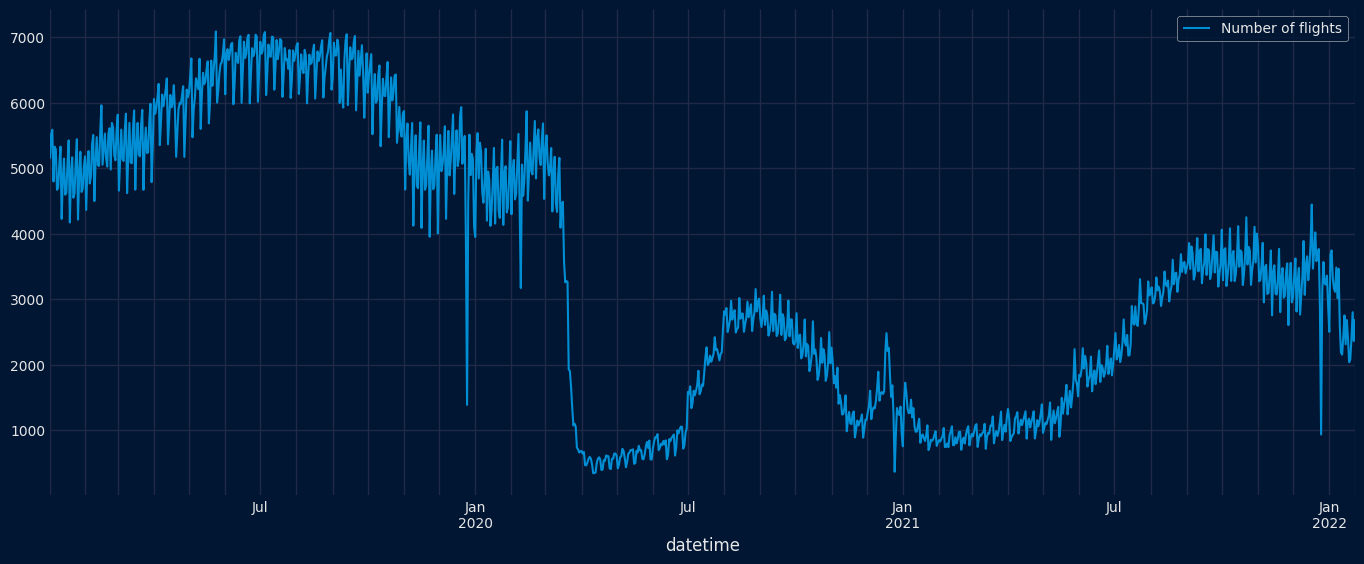

In [11]:
from skforecast.plot import set_dark_theme
set_dark_theme()
fig, ax = plt.subplots(figsize = (15, 6))
data.plot(ax = ax)
ax.legend()
plt.show()

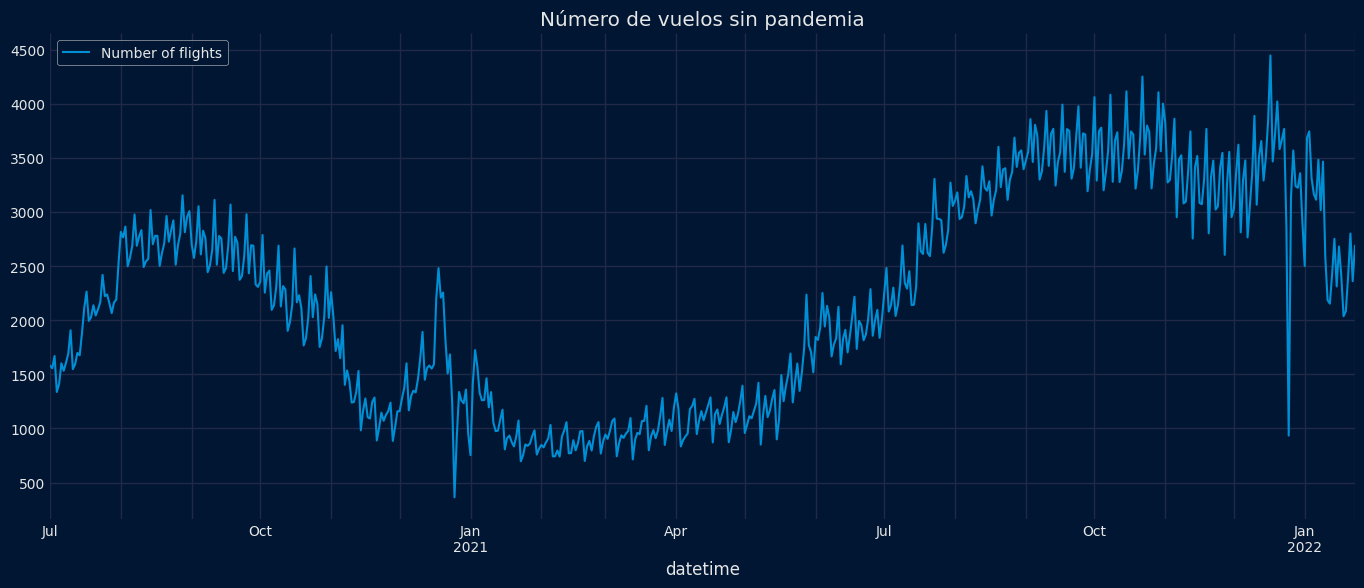

In [48]:
import matplotlib.pyplot as plt
from skforecast.plot import set_dark_theme

# Filtramos los datos para el año 2021
data_sinpandemia = data.loc['2020-07-01':'2022-12-31']

# Graficamos solo ese período
fig, ax = plt.subplots(figsize=(15, 6))
data_sinpandemia.plot(ax=ax)
ax.set_title('Número de vuelos sin pandemia') 
ax.legend()
plt.show()

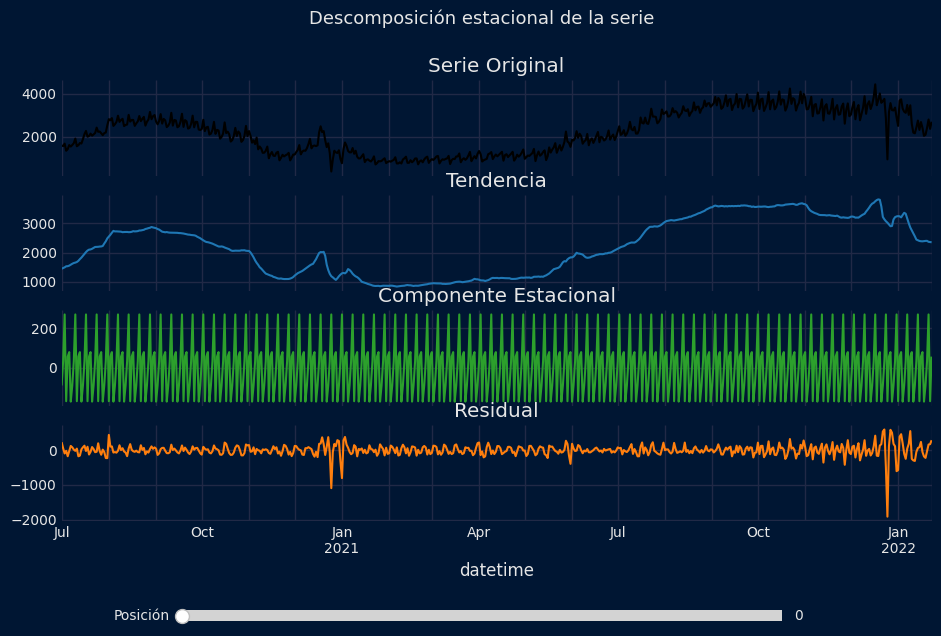

In [49]:
# from statsmodels.tsa.seasonal import seasonal_decompose
# res_decompose = seasonal_decompose(data_sinpandemia['Number of flights'], model = 'additive', extrapolate_trend = 'freq')
# fig, ax = plt.subplots(4, 1, figsize = (9, 6), sharex = True)
# res_decompose.observed.plot(ax = ax[0])
# ax[0].set_title('Serie Original')
# res_decompose.trend.plot(ax = ax[1])
# ax[1].set_title('Tendencia')
# res_decompose.seasonal.plot(ax = ax[2])
# ax[2].set_title('Componente Estacional')
# res_decompose.resid.plot(ax = ax[3])
# ax[3].set_title('Residual')
# fig.suptitle('Descomposición estacional de la serie')
# plt.show()


import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from statsmodels.tsa.seasonal import seasonal_decompose

# --- Descomposición estacional ---
res_decompose = seasonal_decompose(
    data_sinpandemia['Number of flights'], 
    model='additive', 
    extrapolate_trend='freq'
)

# --- Figura principal con 4 subgráficas ---
fig, ax = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
plt.subplots_adjust(bottom=0.25)  # deja espacio para el slider

# Serie original
res_decompose.observed.plot(ax=ax[0], color='black')
ax[0].set_title('Serie Original')

# Tendencia
res_decompose.trend.plot(ax=ax[1], color='tab:blue')
ax[1].set_title('Tendencia')

# Componente estacional
res_decompose.seasonal.plot(ax=ax[2], color='tab:green')
ax[2].set_title('Componente Estacional')

# Residual
res_decompose.resid.plot(ax=ax[3], color='tab:orange')
ax[3].set_title('Residual')

fig.suptitle('Descomposición estacional de la serie', fontsize=13)

# --- Slider para hacer zoom en el eje X ---
ax_slider = plt.axes([0.2, 0.1, 0.6, 0.03])  # posición del slider
slider = Slider(ax_slider, 'Posición', 0, len(res_decompose.observed)-100, valinit=0, valstep=1)

# Función que actualiza el rango visible según el slider
def update(val):
    pos = int(slider.val)
    # Mostrar una ventana de 100 puntos (puedes ajustar ese número)
    for a in ax:
        a.set_xlim(res_decompose.observed.index[pos], res_decompose.observed.index[min(pos+100, len(res_decompose.observed)-1)])
    fig.canvas.draw_idle()

slider.on_changed(update)

plt.show()


# Afectado por la pandemia, se empieza a recuperar

In [44]:
from statsmodels.tsa.stattools import adfuller
print('Test de Estacionariedad')
adfuller_result = adfuller(data_sinpandemia['Number of flights'])
print(f'ADF Estadístico: {adfuller_result[0]}, p-value: {adfuller_result[1]}')

Test de Estacionariedad
ADF Estadístico: -1.1595660407708113, p-value: 0.690743192494219


# No es estacionaria 0.69 > 0.05


Test de Estacionariedad
ADF Estadístico: -5.436063858275792, p-value: 2.8438772923098127e-06


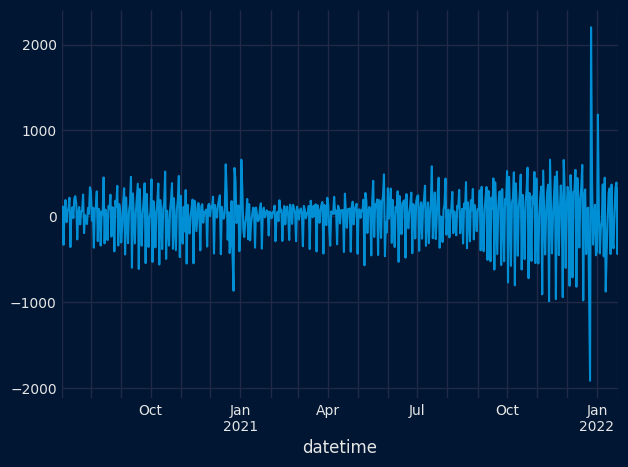

In [45]:
#Hacerla estacionaria

data_diff = data_sinpandemia['Number of flights'].diff().dropna()
print('Test de Estacionariedad')
adfuller_result = adfuller(data_diff)
print(f'ADF Estadístico: {adfuller_result[0]}, p-value: {adfuller_result[1]}')
data_diff.plot()
plt.show()

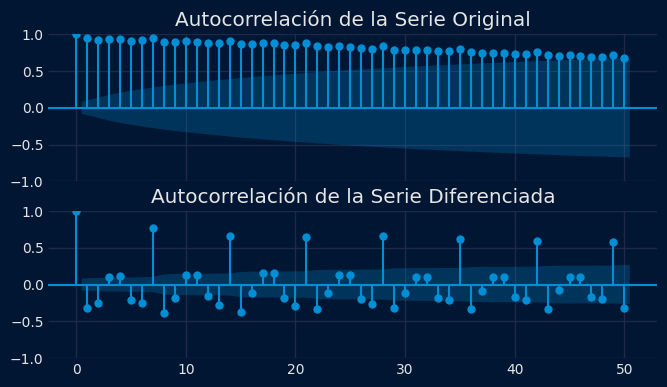

In [46]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#Gráfico de Autocorrelación
fig, ax = plt.subplots(2, 1, figsize = (7, 4), sharex = True)
plot_acf(data_sinpandemia['Number of flights'], ax = ax[0], lags = 50, alpha = 0.05)
ax[0].set_title('Autocorrelación de la Serie Original')
plot_acf(data_diff, ax = ax[1], lags = 50, alpha = 0.05)
ax[1].set_title('Autocorrelación de la Serie Diferenciada')
plt.show()

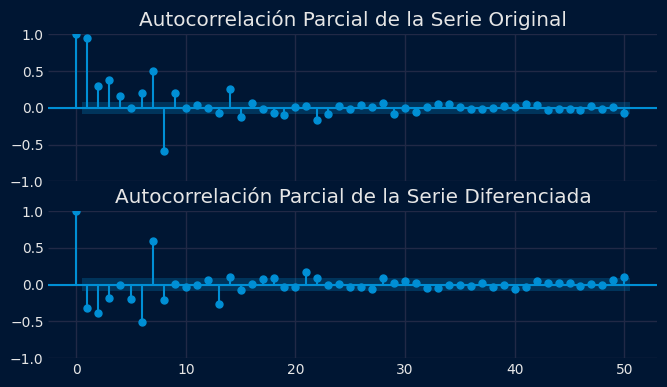

In [47]:
#Gráfico de Autocorrelación Parcial
fig, ax = plt.subplots(2, 1, figsize = (7, 4), sharex = True)
plot_pacf(data_sinpandemia['Number of flights'], ax = ax[0], lags = 50, alpha = 0.05)
ax[0].set_title('Autocorrelación Parcial de la Serie Original')
plot_pacf(data_diff, ax = ax[1], lags = 50, alpha = 0.05)
ax[1].set_title('Autocorrelación Parcial de la Serie Diferenciada')
plt.show()